# Practice 12 — Training Pipeline

준비된 DataLoader 를 사용해 **모델을 학습**합니다.

| 단계 | 내용 |
|------|------|
| 모델 정의 | `nn.Module` 상속 클래스 |
| Loss + Optimizer | `CrossEntropyLoss`, `Adam` |
| `train` / `evaluate` 함수 | 학습 루프를 함수로 묶어 재사용 가능한 형태로 |
| 학습 + 시각화 | Loss/Accuracy 학습 곡선 |


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

# GPU 자동 선택 (CPU 환경이면 .to(device) 는 자동 무시됨)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# 데이터 준비
digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

mu, sigma = X_train.mean(0), X_train.std(0) + 1e-8
X_train_s = (X_train - mu) / sigma
X_test_s  = (X_test  - mu) / sigma

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train_s), torch.LongTensor(y_train)),
    batch_size=16, shuffle=True)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test_s), torch.LongTensor(y_test)),
    batch_size=16, shuffle=False)

print(f'Train: {len(y_train)}, Test: {len(y_test)}')


device: cuda
Train: 1437, Test: 360


---
# 1. 모델 정의 (nn.Module)

In [2]:
class DigitMLP(nn.Module):
    # 간단한 3층 MLP: 64 → 128 → 64 → 10
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.net(x)

model = DigitMLP().to(device)
print(model)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print()
print(f"Total parameters: {total_params:,}")


DigitMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total parameters: 17,226


---
# 2. Loss, Optimizer 설정

In [3]:
# CrossEntropyLoss: softmax + NLL loss (내부에서 softmax 자동 적용)
criterion = nn.CrossEntropyLoss()

# Adam optimizer
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss     : {criterion}")
print(f"Optimizer: Adam (lr={learning_rate})")

Loss     : CrossEntropyLoss()
Optimizer: Adam (lr=0.001)


---
# 3. `train` + `evaluate` 함수

매 epoch 학습 루프를 직접 작성하는 대신 **두 함수로 묶어** 두면 이후 다른 모델·데이터에 그대로 재사용할 수 있습니다.

| 함수 | 역할 |
|------|------|
| `train(model, train_loader, test_loader, optimizer, epochs, device)` | epochs 만큼 학습 + 매 epoch 평가, `(train_losses, test_losses, test_accs)` 반환 |
| `evaluate(model, loader, device)` | 한 번 평가, `(loss, accuracy)` 반환 |

- `model.train()` / `model.eval()` 모드 전환은 함수가 내부에서 처리
- `device` 인자: CPU/GPU 어디서든 동일 코드 (CPU 환경이면 `.to(device)` 는 무시됨)


In [4]:
# 학습 - epochs 만큼 학습 + 매 epoch 평가
# (train_losses, test_losses, test_accs) 반환
def train(model, train_loader, test_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses, test_accs = [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, count = 0.0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(Y_batch)
            count += len(Y_batch)
        train_loss = loss_sum / count
        test_loss, test_acc = evaluate(model, test_loader, device)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  train_loss={train_loss:.4f}  test_loss={test_loss:.4f}  test_acc={test_acc:.4f}')
    return train_losses, test_losses, test_accs


# 평가 - (loss, accuracy) 반환
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item() * len(Y_batch)
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
    return loss_sum / count, correct / count


---
# 4. 학습

In [5]:
train_losses, test_losses, test_accs = train(
    model, train_loader, test_loader, optimizer, epochs=50, device=device)

print()
print(f'Final train_loss={train_losses[-1]:.4f}  test_loss={test_losses[-1]:.4f}  test_acc={test_accs[-1]:.4f}')


  Epoch   1/50  train_loss=1.3878  test_loss=0.4552  test_acc=0.8944


  Epoch  10/50  train_loss=0.0074  test_loss=0.0698  test_acc=0.9806


  Epoch  20/50  train_loss=0.0012  test_loss=0.0682  test_acc=0.9806


  Epoch  30/50  train_loss=0.0004  test_loss=0.0705  test_acc=0.9806


  Epoch  40/50  train_loss=0.0002  test_loss=0.0728  test_acc=0.9833


  Epoch  50/50  train_loss=0.0001  test_loss=0.0755  test_acc=0.9806

Final train_loss=0.0001  test_loss=0.0755  test_acc=0.9806


---
# 5. 학습 곡선 시각화

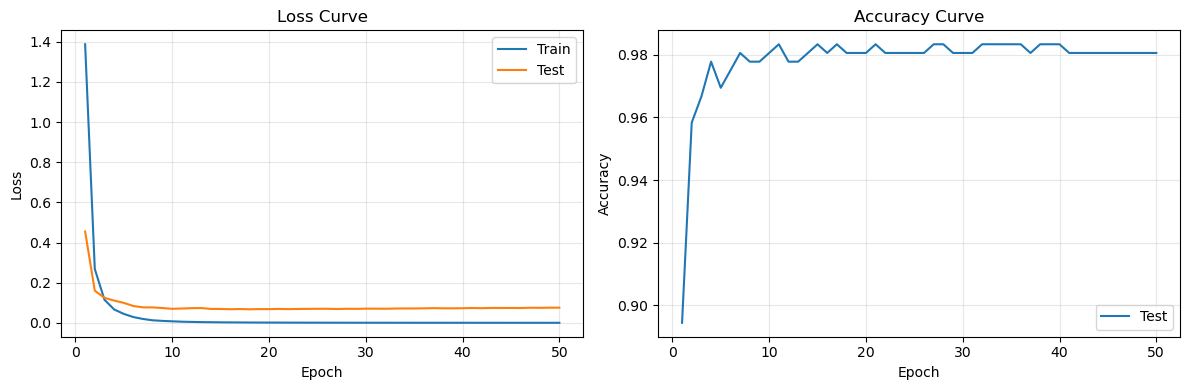

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label='Train')
axes[0].plot(epochs_range, test_losses, label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, test_accs, label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---
## 정리

`train` + `evaluate` 두 함수로 학습 루프를 묶었습니다. 데이터·모델만 바꾸면 그대로 사용할 수 있는 표준 형태입니다.
